<a href="https://colab.research.google.com/github/YousraAndoulla/ecommerce-cohort-retention-analysis/blob/main/cohort_retention_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "mkechinov/ecommerce-events-history-in-cosmetics-shop"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-events-history-in-cosmetics-shop' dataset.
Path to dataset files: /kaggle/input/ecommerce-events-history-in-cosmetics-shop


In [3]:
import os

print(os.listdir(path))

['2019-Nov.csv', '2020-Feb.csv', '2019-Oct.csv', '2019-Dec.csv', '2020-Jan.csv']


In [4]:
for file in os.listdir(path):
    file_path = os.path.join(path, file)

    if os.path.isfile(file_path):
        size_mb = os.path.getsize(file_path) / (1024 ** 2)
        print(f"{file}: {size_mb:.2f} MB")

2019-Nov.csv: 520.55 MB
2020-Feb.csv: 466.16 MB
2019-Oct.csv: 460.19 MB
2019-Dec.csv: 396.06 MB
2020-Jan.csv: 478.55 MB


In [6]:
import pandas as pd

dec_file = os.path.join(path, "2019-Dec.csv")

df_dec = pd.read_csv(
    dec_file,
    usecols=['event_time', 'user_id']
)

print(df_dec.head())

                event_time    user_id
0  2019-12-01 00:00:00 UTC  576802932
1  2019-12-01 00:00:00 UTC  412120092
2  2019-12-01 00:00:02 UTC  494077766
3  2019-12-01 00:00:05 UTC  348405118
4  2019-12-01 00:00:07 UTC  576005683


**. Reduce the data to one row per user per day. This is important because one user can generate thousands of events in one day**.

In [7]:
import pandas as pd
import os

files = [
    "2019-Oct.csv",
    "2019-Nov.csv",
    "2019-Dec.csv",
    "2020-Jan.csv",
    "2020-Feb.csv"
]

dfs = []

for file in files:
    file_path = os.path.join(path, file)

    print("Loading:", file)

    temp = pd.read_csv(
        file_path,
        usecols=['event_time', 'user_id']
    )

    # Convert event_time to datetime
    temp['event_time'] = pd.to_datetime(temp['event_time'])

    # Keep only the date
    temp['visit_date'] = temp['event_time'].dt.date

    # One user = one visit per day
    temp = temp[['user_id', 'visit_date']].drop_duplicates()

    dfs.append(temp)

    print("Unique user-days:", len(temp))

df = pd.concat(dfs, ignore_index=True)

print("\nFinished!")
print("Total unique user-days:", len(df))

Loading: 2019-Oct.csv
Unique user-days: 556540
Loading: 2019-Nov.csv
Unique user-days: 549328
Loading: 2019-Dec.csv
Unique user-days: 529025
Loading: 2020-Jan.csv
Unique user-days: 599798
Loading: 2020-Feb.csv
Unique user-days: 570213

Finished!
Total unique user-days: 2804904


In [8]:
print(df.head(20))
print("\nShape:", df.shape)
print("\nNumber of unique users:", df['user_id'].nunique())

      user_id  visit_date
0   463240011  2019-10-01
1   429681830  2019-10-01
2   430174032  2019-10-01
3   377667011  2019-10-01
4   467916806  2019-10-01
5   385985999  2019-10-01
6   474232307  2019-10-01
7   555446068  2019-10-01
8   546705258  2019-10-01
9   555442940  2019-10-01
10  507355498  2019-10-01
11  524009100  2019-10-01
12  543446752  2019-10-01
13  555447840  2019-10-01
14  520558067  2019-10-01
15  462033176  2019-10-01
16  514753614  2019-10-01
17  401329661  2019-10-01
18  549297581  2019-10-01
19  555416325  2019-10-01

Shape: (2804904, 2)

Number of unique users: 1639358


*   visit_date
When did the user visit?
*  cohort_date
When did the user visit for the FIRST time?



In [10]:
df['cohort_date'] = (
    df.groupby('user_id')['visit_date']
      .transform('min')
)

In [11]:
print(df.head(20))

      user_id  visit_date cohort_date
0   463240011  2019-10-01  2019-10-01
1   429681830  2019-10-01  2019-10-01
2   430174032  2019-10-01  2019-10-01
3   377667011  2019-10-01  2019-10-01
4   467916806  2019-10-01  2019-10-01
5   385985999  2019-10-01  2019-10-01
6   474232307  2019-10-01  2019-10-01
7   555446068  2019-10-01  2019-10-01
8   546705258  2019-10-01  2019-10-01
9   555442940  2019-10-01  2019-10-01
10  507355498  2019-10-01  2019-10-01
11  524009100  2019-10-01  2019-10-01
12  543446752  2019-10-01  2019-10-01
13  555447840  2019-10-01  2019-10-01
14  520558067  2019-10-01  2019-10-01
15  462033176  2019-10-01  2019-10-01
16  514753614  2019-10-01  2019-10-01
17  401329661  2019-10-01  2019-10-01
18  549297581  2019-10-01  2019-10-01
19  555416325  2019-10-01  2019-10-01


**Calculate how many days after the first visit**

In [12]:
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['cohort_date'] = pd.to_datetime(df['cohort_date'])

In [13]:
df['day_number'] = (
    df['visit_date'] - df['cohort_date']
).dt.days

In [14]:
print(
    df[
        ['user_id', 'cohort_date', 'visit_date', 'day_number']
    ].head(20)
)

      user_id cohort_date visit_date  day_number
0   463240011  2019-10-01 2019-10-01           0
1   429681830  2019-10-01 2019-10-01           0
2   430174032  2019-10-01 2019-10-01           0
3   377667011  2019-10-01 2019-10-01           0
4   467916806  2019-10-01 2019-10-01           0
5   385985999  2019-10-01 2019-10-01           0
6   474232307  2019-10-01 2019-10-01           0
7   555446068  2019-10-01 2019-10-01           0
8   546705258  2019-10-01 2019-10-01           0
9   555442940  2019-10-01 2019-10-01           0
10  507355498  2019-10-01 2019-10-01           0
11  524009100  2019-10-01 2019-10-01           0
12  543446752  2019-10-01 2019-10-01           0
13  555447840  2019-10-01 2019-10-01           0
14  520558067  2019-10-01 2019-10-01           0
15  462033176  2019-10-01 2019-10-01           0
16  514753614  2019-10-01 2019-10-01           0
17  401329661  2019-10-01 2019-10-01           0
18  549297581  2019-10-01 2019-10-01           0
19  555416325  2019-

**Count unique users per cohort and day**

In [15]:
cohort_data = (
    df.groupby(['cohort_date', 'day_number'])['user_id']
      .nunique()
      .reset_index()
)

print(cohort_data.head(20))

   cohort_date  day_number  user_id
0   2019-10-01           0    19230
1   2019-10-01           1     2120
2   2019-10-01           2     1475
3   2019-10-01           3     1232
4   2019-10-01           4      926
5   2019-10-01           5      946
6   2019-10-01           6     1139
7   2019-10-01           7      985
8   2019-10-01           8      932
9   2019-10-01           9      867
10  2019-10-01          10      826
11  2019-10-01          11      634
12  2019-10-01          12      693
13  2019-10-01          13      851
14  2019-10-01          14      806
15  2019-10-01          15      750
16  2019-10-01          16      755
17  2019-10-01          17      689
18  2019-10-01          18      535
19  2019-10-01          19      568


**Create the cohort table**

In [16]:
cohort_pivot = cohort_data.pivot_table(
    index='cohort_date',
    columns='day_number',
    values='user_id'
)

print(cohort_pivot)

day_number       0       1       2       3      4      5       6      7    \
cohort_date                                                                 
2019-10-01   19230.0  2120.0  1475.0  1232.0  926.0  946.0  1139.0  985.0   
2019-10-02   31739.0  1492.0   881.0   639.0  621.0  754.0   700.0  711.0   
2019-10-03   13356.0  1181.0   575.0   569.0  670.0  555.0   541.0  510.0   
2019-10-04   11438.0   853.0   552.0   580.0  466.0  428.0   397.0  346.0   
2019-10-05   11997.0   902.0   514.0   418.0  388.0  342.0   298.0  316.0   
...              ...     ...     ...     ...    ...    ...     ...    ...   
2020-02-25   10342.0   652.0   333.0   239.0  178.0    NaN     NaN    NaN   
2020-02-26   10432.0   685.0   331.0   211.0    NaN    NaN     NaN    NaN   
2020-02-27   10398.0   605.0   247.0     NaN    NaN    NaN     NaN    NaN   
2020-02-28    9994.0   542.0     NaN     NaN    NaN    NaN     NaN    NaN   
2020-02-29   10566.0     NaN     NaN     NaN    NaN    NaN     NaN    NaN   

**calculate cohort size**

cohort_size now contains the number of users on Day 0 for each cohort.

In [18]:
cohort_size = cohort_pivot.iloc[:, 0]

print(cohort_size)

cohort_date
2019-10-01    19230.0
2019-10-02    31739.0
2019-10-03    13356.0
2019-10-04    11438.0
2019-10-05    11997.0
               ...   
2020-02-25    10342.0
2020-02-26    10432.0
2020-02-27    10398.0
2020-02-28     9994.0
2020-02-29    10566.0
Name: 0, Length: 152, dtype: float64


**calculate retention:**

In [19]:
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

print(retention_matrix)

day_number   0         1         2         3         4         5         6    \
cohort_date                                                                    
2019-10-01   1.0  0.110244  0.076703  0.064067  0.048154  0.049194  0.059230   
2019-10-02   1.0  0.047008  0.027758  0.020133  0.019566  0.023756  0.022055   
2019-10-03   1.0  0.088425  0.043052  0.042603  0.050165  0.041554  0.040506   
2019-10-04   1.0  0.074576  0.048260  0.050708  0.040741  0.037419  0.034709   
2019-10-05   1.0  0.075185  0.042844  0.034842  0.032341  0.028507  0.024840   
...          ...       ...       ...       ...       ...       ...       ...   
2020-02-25   1.0  0.063044  0.032199  0.023110  0.017211       NaN       NaN   
2020-02-26   1.0  0.065663  0.031729  0.020226       NaN       NaN       NaN   
2020-02-27   1.0  0.058184  0.023755       NaN       NaN       NaN       NaN   
2020-02-28   1.0  0.054233       NaN       NaN       NaN       NaN       NaN   
2020-02-29   1.0       NaN       NaN    

In [20]:
retention_percentage = (retention_matrix * 100).round(2)

print(retention_percentage)

day_number     0      1     2     3     4     5     6     7     8     9    \
cohort_date                                                                 
2019-10-01   100.0  11.02  7.67  6.41  4.82  4.92  5.92  5.12  4.85  4.51   
2019-10-02   100.0   4.70  2.78  2.01  1.96  2.38  2.21  2.24  2.04  1.79   
2019-10-03   100.0   8.84  4.31  4.26  5.02  4.16  4.05  3.82  3.45  2.75   
2019-10-04   100.0   7.46  4.83  5.07  4.07  3.74  3.47  3.03  2.86  2.63   
2019-10-05   100.0   7.52  4.28  3.48  3.23  2.85  2.48  2.63  2.52  2.13   
...            ...    ...   ...   ...   ...   ...   ...   ...   ...   ...   
2020-02-25   100.0   6.30  3.22  2.31  1.72   NaN   NaN   NaN   NaN   NaN   
2020-02-26   100.0   6.57  3.17  2.02   NaN   NaN   NaN   NaN   NaN   NaN   
2020-02-27   100.0   5.82  2.38   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2020-02-28   100.0   5.42   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2020-02-29   100.0    NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

**visualize the retention matrix as a heatmap.**


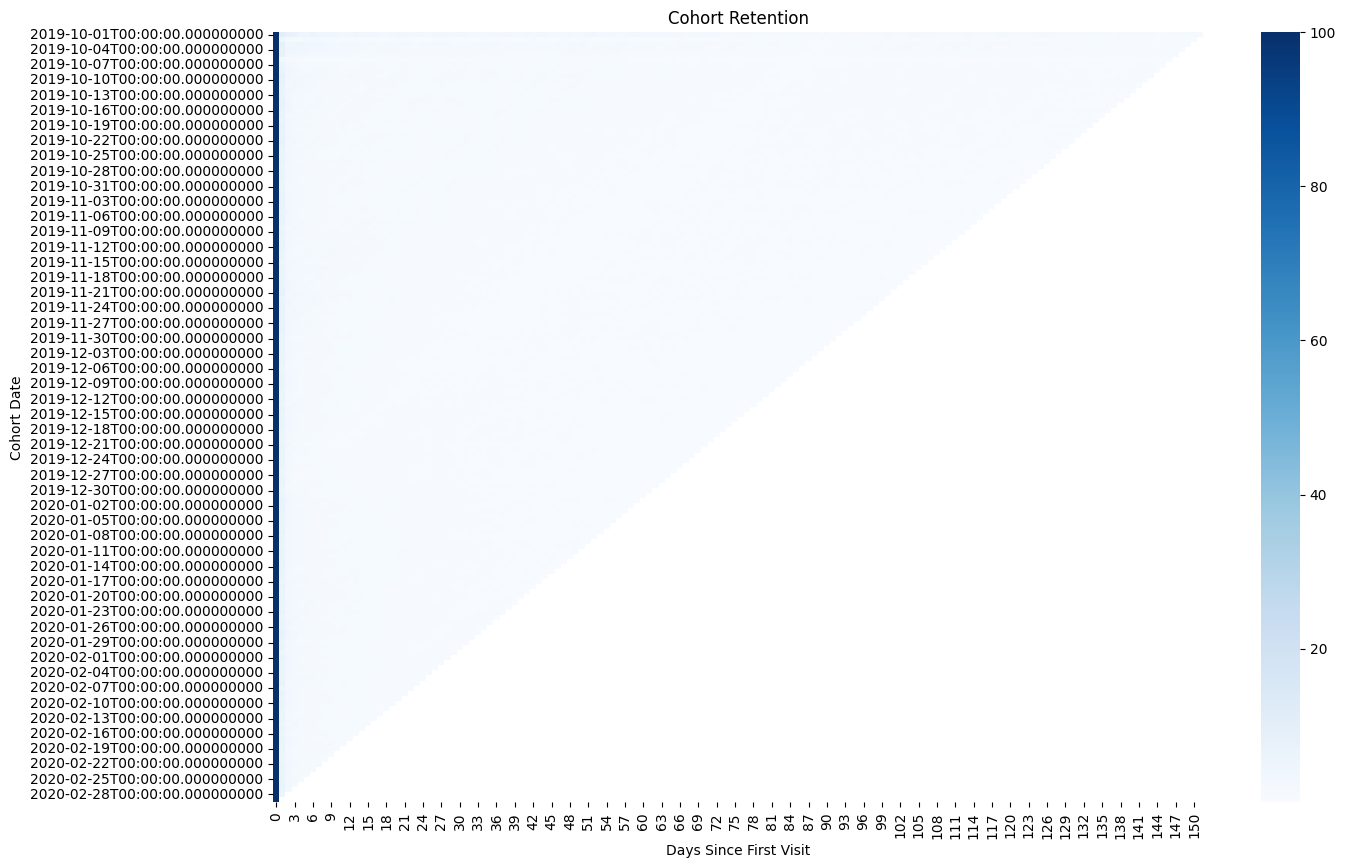

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

sns.heatmap(
    retention_percentage,
    cmap='Blues',
    annot=False
)

plt.title('Cohort Retention')
plt.xlabel('Days Since First Visit')
plt.ylabel('Cohort Date')

plt.show()

7-day **retention**

In [22]:
day_7_retention = retention_percentage[7]

print(day_7_retention)

cohort_date
2019-10-01    5.12
2019-10-02    2.24
2019-10-03    3.82
2019-10-04    3.03
2019-10-05    2.63
              ... 
2020-02-25     NaN
2020-02-26     NaN
2020-02-27     NaN
2020-02-28     NaN
2020-02-29     NaN
Name: 7, Length: 152, dtype: float64


**visualize only the 7-day retention**



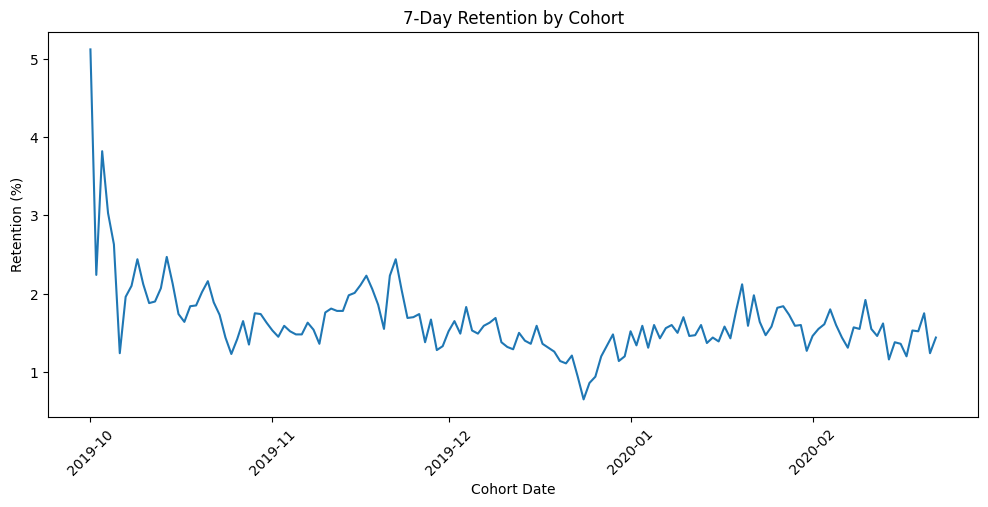

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(day_7_retention)

plt.title('7-Day Retention by Cohort')
plt.xlabel('Cohort Date')
plt.ylabel('Retention (%)')

plt.xticks(rotation=45)
plt.show()

**calculate the average 7-day retention**

In [24]:
average_7_day_retention = day_7_retention.mean()

print(f"Average 7-Day Retention: {average_7_day_retention:.2f}%")

Average 7-Day Retention: 1.65%


In [25]:
999999print("7-Day Retention Analysis")
print("-------------------------")
print(f"Average 7-Day Retention: {average_7_day_retention:.2f}%")
print(f"Best 7-Day Retention: {day_7_retention.max():.2f}%")
print(f"Worst 7-Day Retention: {day_7_retention.min():.2f}%")

7-Day Retention Analysis
-------------------------
Average 7-Day Retention: 1.65%
Best 7-Day Retention: 5.12%
Worst 7-Day Retention: 0.65%
